<a href="https://colab.research.google.com/github/rachit2005/Deep-Learning/blob/main/rnn_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

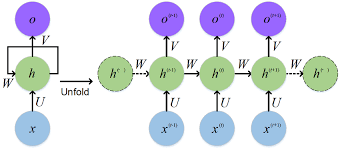

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np

In [52]:
# Character set and mapping
data = ["hello", "world", "pytorch", "rnn"]

chars = list(set(''.join(data)))
print(chars)
char_to_ix = {ch: i for i, ch in enumerate(chars)}
ix_to_char = {i: ch for ch, i in char_to_ix.items()}


# One-hot encode
def one_hot(idx, size):
    vec = torch.zeros(size)
    vec[idx] = 1.0
    return vec

['t', 'e', 'w', 'd', 'o', 'l', 'y', 'h', 'p', 'n', 'c', 'r']


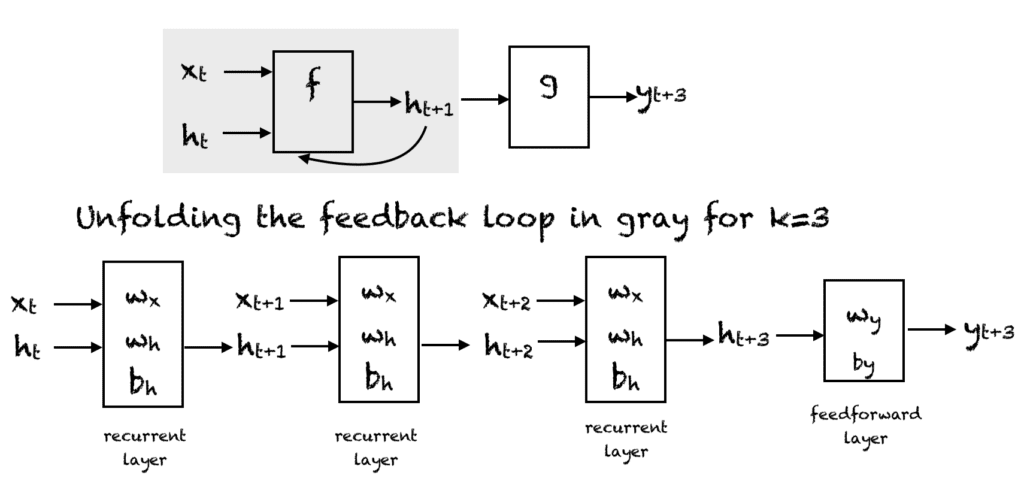

In [54]:
hidden_size = 16
vocab_size = len(chars) # --> input_size , output_size

In [56]:
i_to_h = torch.randn(hidden_size , vocab_size) * 0.01
h_to_h = torch.randn(hidden_size ,hidden_size) * 0.01
h_to_output = torch.randn( vocab_size, hidden_size) * 0.01

bh = torch.randn(hidden_size)
boutput = torch.randn(vocab_size)

parameters = [i_to_h ,h_to_h , h_to_output , bh ,boutput]
for p in parameters:
  p.requires_grad = True

# RNN Maths

h_t = tanh(W_ih * x_t + W_hh * h_{t-1} + b_h)  
y_t = W_ho * h_t + b_o

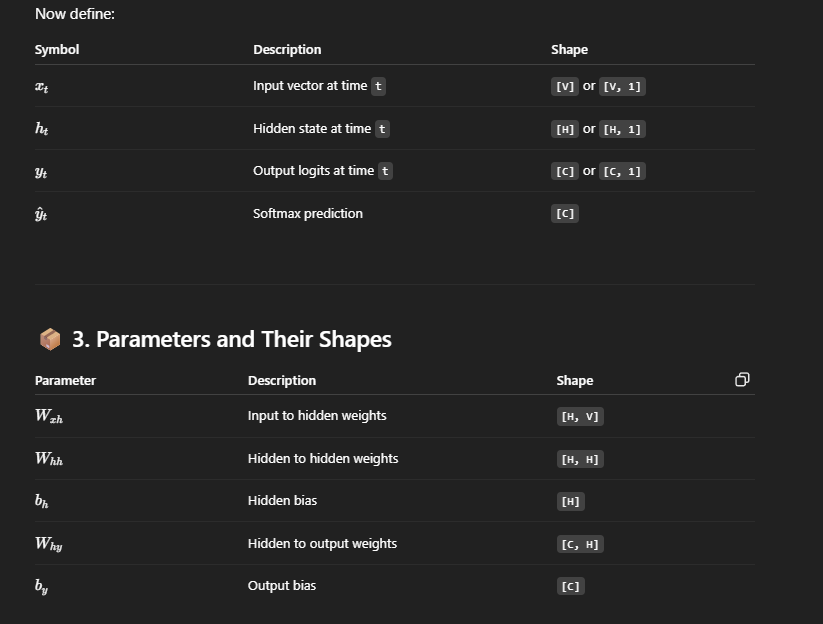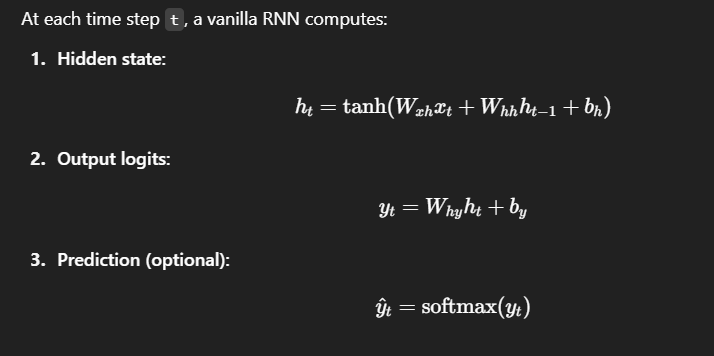

In [60]:
def rnn_step(x_t , h_prev):
  h_t = torch.tanh(i_to_h @ x_t + h_to_h @ h_prev + bh)
  y_t = h_to_output @ h_t + boutput

  return y_t , h_t

In [71]:
lr = 0.01
epochs = 1000

for epoch in range(epochs):
  total_loss = 0.0

  for word in data:
    inputs = [one_hot(char_to_ix[ch] , vocab_size) for ch in word[:-1]]
    target = [char_to_ix[ch] for ch in word[1:]]

    h_prev = torch.zeros(hidden_size , requires_grad=True)
    loss = 0

    outputs = []
    hidden_state = [h_prev]

    # forward pass
    for x_t , target in zip(inputs , target):
      # print(x_t.shape)
      y_t , h_t = rnn_step(x_t ,hidden_state[-1])
      hidden_state.append(h_t)
      outputs.append(y_t)

      loss += F.cross_entropy(outputs[-1] , torch.tensor(target))


    # setting the zero grad
    for p in parameters:
      p.grad = None
    loss.backward()

    for p in parameters:
      p.data -= lr * p.grad
    total_loss += loss.item()


    print(f"Epoch {epoch}, Loss: {total_loss:.4f}")


Epoch 0, Loss: 0.0355
Epoch 0, Loss: 0.0635
Epoch 0, Loss: 0.1109
Epoch 0, Loss: 0.1233
Epoch 1, Loss: 0.0354
Epoch 1, Loss: 0.0635
Epoch 1, Loss: 0.1109
Epoch 1, Loss: 0.1232
Epoch 2, Loss: 0.0354
Epoch 2, Loss: 0.0634
Epoch 2, Loss: 0.1108
Epoch 2, Loss: 0.1231
Epoch 3, Loss: 0.0354
Epoch 3, Loss: 0.0634
Epoch 3, Loss: 0.1107
Epoch 3, Loss: 0.1230
Epoch 4, Loss: 0.0353
Epoch 4, Loss: 0.0633
Epoch 4, Loss: 0.1106
Epoch 4, Loss: 0.1229
Epoch 5, Loss: 0.0353
Epoch 5, Loss: 0.0633
Epoch 5, Loss: 0.1105
Epoch 5, Loss: 0.1228
Epoch 6, Loss: 0.0353
Epoch 6, Loss: 0.0632
Epoch 6, Loss: 0.1104
Epoch 6, Loss: 0.1227
Epoch 7, Loss: 0.0353
Epoch 7, Loss: 0.0632
Epoch 7, Loss: 0.1104
Epoch 7, Loss: 0.1226
Epoch 8, Loss: 0.0352
Epoch 8, Loss: 0.0631
Epoch 8, Loss: 0.1103
Epoch 8, Loss: 0.1225
Epoch 9, Loss: 0.0352
Epoch 9, Loss: 0.0631
Epoch 9, Loss: 0.1102
Epoch 9, Loss: 0.1225
Epoch 10, Loss: 0.0352
Epoch 10, Loss: 0.0630
Epoch 10, Loss: 0.1101
Epoch 10, Loss: 0.1224
Epoch 11, Loss: 0.0352
Epoch

In [76]:
def predict(start_char , length=5):
  h_prev = torch.zeros(hidden_size)
  ch = start_char
  output = ch

  for _ in range(length):
    x_t = one_hot(char_to_ix[ch] , vocab_size) # -->[vocab_size]
    y_t, h_t = rnn_step(x_t , h_prev)
    print(y_t.shape) # --> [vocab_size]
    probs = F.softmax(y_t , dim=0)
    ch_idx =  torch.multinomial(probs, 1).item()
    ch = ix_to_char[ch_idx] # assigning the next element : passing the output char as input to predict the next one

    output += ch

  return output

print(predict('p' , 6))

torch.Size([12])
torch.Size([12])
torch.Size([12])
torch.Size([12])
torch.Size([12])
torch.Size([12])
pyyennn


In [ ]:
vocab_size = 4 # (v) , input_size
hidden_size = 8 # (h)
output_vocab_size = 4 # (c), target_size

In [ ]:
'''  x_t (4,)
             |
         Wxh @ x_t
             |
        Whh @ h_{t-1}
             |
        [sum + bh] ---> z_t (8,)
             |
         tanh(z_t)
             |
            h_t (8,) --------> Why @ h_t + by
                                 |
                             y_t (4,) ----> softmax → prediction
'''

# this will run for every character in the sequence thats why we take h_prev for starting hidden state

'  x_t (4,)\n             |\n         Wxh @ x_t\n             |\n        Whh @ h_{t-1}\n             |\n        [sum + bh] ---> z_t (8,)\n             |\n         tanh(z_t)\n             |\n            h_t (8,) --------> Why @ h_t + by\n                                 |\n                             y_t (4,) ----> softmax → prediction\n'

In [ ]:
xt = torch.randn(vocab_size) # [4]
ht = torch.randn(hidden_size) # [8]

h_prev = torch.randn(hidden_size)

input_to_hidden_weights = torch.randn(hidden_size , vocab_size) # [8,4]
hidden_to_hidden_weigths = torch.randn(hidden_size , hidden_size) # [8,8]
hidden_to_output_weights = torch.randn(output_vocab_size , hidden_size) # [4,8]

hidden_bias = torch.randn(hidden_size)
output_bias = torch.randn(vocab_size)

parameters = [input_to_hidden_weights , hidden_to_hidden_weigths , hidden_to_output_weights , hidden_bias , output_bias]

print(input_to_hidden_weights.shape)
print(hidden_to_hidden_weigths.shape)
print(hidden_to_output_weights.shape)
print(hidden_bias.shape)
print(output_bias.shape)

torch.Size([8, 4])
torch.Size([8, 8])
torch.Size([4, 8])
torch.Size([8])
torch.Size([4])


In [ ]:
h_t = torch.tanh(input_to_hidden_weights @ xt + hidden_to_hidden_weigths @ h_prev + hidden_bias)
h_t.shape

torch.Size([8])

In [ ]:
y_t = hidden_to_output_weights @ h_t + output_bias
y_t.shape

torch.Size([4])